#Before running this code, you must download the shared model to your own Drive.

##model drive link: https://drive.google.com/file/d/1wG8AtZx_W-2E9ZRa58NMbwMfg-onu2WZ/view?usp=sharing

In [3]:
import os
from google.colab import drive
import torch
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FILL PROMPT FOR FACE DESCRIPTION!!!!!!

In [7]:
prompt="a frontal face photo of a young woman with brown hair and lipstick, realistic, high quality"

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ LoRA yüklendi


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Kaydedildi: ./outputs/generated.png


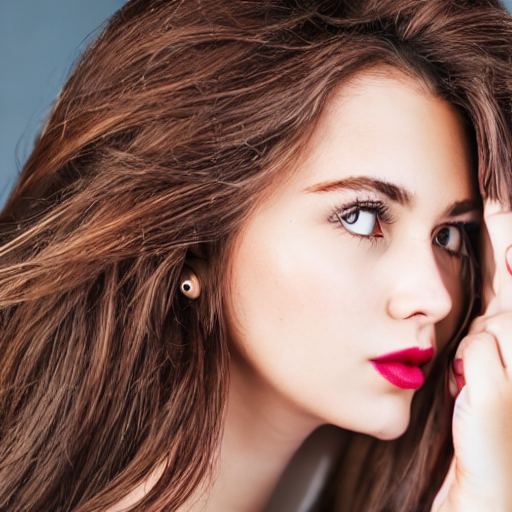

In [8]:
import torch
from diffusers import StableDiffusionPipeline
from peft import LoraConfig
import os

# =========================
# CONFIG
# =========================

MODEL_ID = "runwayml/stable-diffusion-v1-5"
LORA_CKPT = "/content/drive/MyDrive/sd15_face_lora/lora_step_1500.pt"
OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda"

# =========================
# 1) Base model yükle
# =========================

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

# =========================
# 2) LoRA config (training ile aynı!)
# =========================

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
)

pipe.unet.add_adapter(lora_config)

# =========================
# 3) LoRA checkpoint yükle
# =========================

state_dict = torch.load(LORA_CKPT, map_location="cpu")
pipe.unet.load_state_dict(state_dict, strict=False)

print("✅ LoRA yüklendi")

# =========================
# 4) Prompt al ve üret
# =========================



with torch.autocast("cuda"):
    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.0
    ).images[0]

# =========================
# 5) Kaydet
# =========================

output_path = os.path.join(OUTPUT_DIR, "generated.png")
image.save(output_path)

print(f"✅ Kaydedildi: {output_path}")
from IPython.display import display

display(image)